In [11]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target
X.shape

(150, 4)

<Axes: >

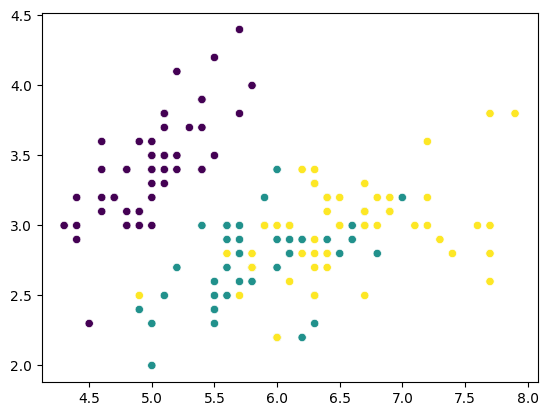

In [8]:
# Visualize
sns.scatterplot(x=X[:,0], y=X[:,1], c=y)

In [9]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Dimensionality Reduction (Optional)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

<Axes: >

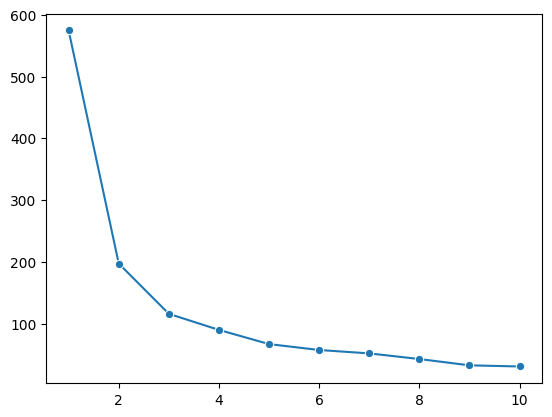

In [18]:
# Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1, 11), y=wcss, marker='o')

<Axes: >

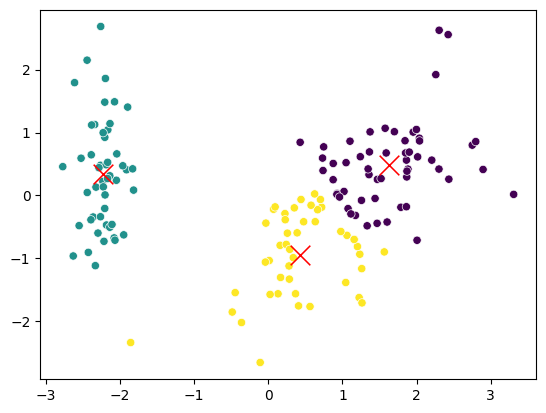

In [20]:
# KMeans
kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker='x', c="red", s=200)